# CVE Exploitability Prediction — Results Overview

Projet de fin d'étude — DU Data Analytics, Paris 1 Panthéon-Sorbonne (2025-2026)

Ce notebook synthétise les résultats des étapes 1 à 3 du pipeline :
1. Collecte (NVD, EPSS, CISA KEV)
2. Feature engineering
3. Modélisation (XGBoost, LightGBM, Random Forest, régression logistique) vs. baseline EPSS

Les données et modèles sont produits par les scripts de `src/` (`src/collect`, `src/features`, `src/models`) — ce notebook ne fait que les charger et les visualiser.

## 1. Collecte des données

In [1]:
import sqlite3
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src.config import DB_PATH, PROCESSED_DIR

conn = sqlite3.connect(DB_PATH)
counts = {
    "NVD (cves)": conn.execute("SELECT COUNT(*) FROM cves").fetchone()[0],
    "EPSS (epss_scores)": conn.execute("SELECT COUNT(*) FROM epss_scores").fetchone()[0],
    "CISA KEV (kev)": conn.execute("SELECT COUNT(*) FROM kev").fetchone()[0],
}
counts

{'NVD (cves)': 378393, 'EPSS (epss_scores)': 360399, 'CISA KEV (kev)': 1665}

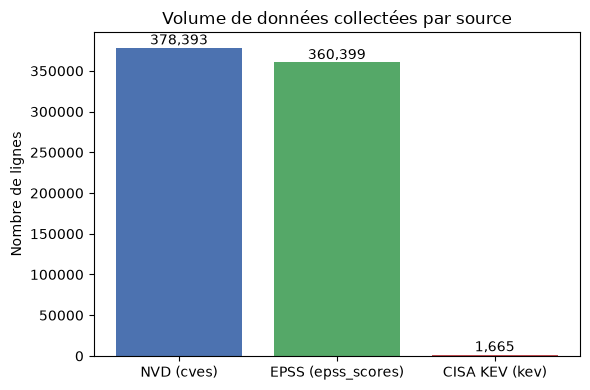

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.keys(), counts.values(), color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Nombre de lignes")
ax.set_title("Volume de données collectées par source")
for i, v in enumerate(counts.values()):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 2. Feature engineering — exploration

In [3]:
features = pd.read_csv(PROCESSED_DIR / "features.csv")
print(f"{len(features):,} CVE au total, {features['is_exploited'].sum():,} exploitées "
      f"({100 * features['is_exploited'].mean():.2f}%)")
features.head()

378,393 CVE au total, 1,665 exploitées (0.44%)


,cve_id,published_date,cvss_base_score,cvss_impact_score,cvss_exploitability_score,cvss_attack_vector,cvss_attack_complexity,cvss_privileges_required,cvss_user_interaction,cvss_scope,has_cwe,cwe_category,reference_count,days_since_publication,epss_score,epss_percentile,vendor_category,has_exploit_keyword,is_exploited
0,CVE-2010-0188,2010-02-22T13:00:02.127,7.8,5.9,1.8,2.0,0.0,1.0,0.0,0.0,False,none,21,6019,0.88246,0.99756,other,False,1
1,CVE-2010-0738,2010-04-28T22:30:00.447,5.3,1.4,3.9,0.0,0.0,0.0,0.0,0.0,True,other,27,5954,0.79415,0.99569,web,False,1
2,CVE-2010-1428,2010-04-28T22:30:00.793,7.5,3.6,3.9,0.0,0.0,0.0,0.0,0.0,True,other,23,5954,0.62308,0.99113,other,False,1
3,CVE-2010-2861,2010-08-11T18:47:51.157,9.8,5.9,3.9,0.0,0.0,0.0,0.0,0.0,True,path-traversal,11,5849,0.99721,0.99952,other,True,1
4,CVE-2012-0507,2012-06-07T22:55:17.883,9.8,5.9,3.9,0.0,0.0,0.0,0.0,0.0,True,other,45,5183,0.98113,0.99909,other,False,1


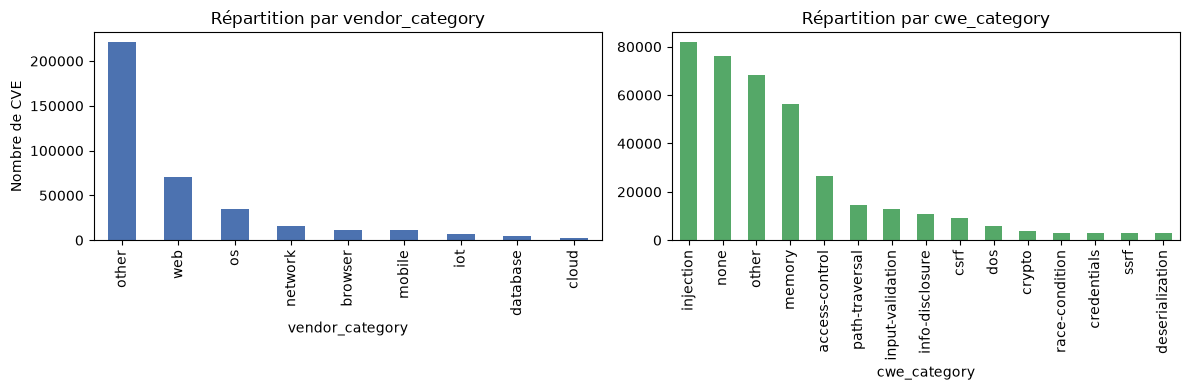

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

features["vendor_category"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Répartition par vendor_category")
axes[0].set_ylabel("Nombre de CVE")

features["cwe_category"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Répartition par cwe_category")

plt.tight_layout()
plt.show()

### CVSS vs EPSS, selon le statut d'exploitation

C'est le cœur de la problématique du projet : le CVSS (sévérité théorique) et l'EPSS (probabilité réelle d'exploitation) ne sont pas toujours alignés.

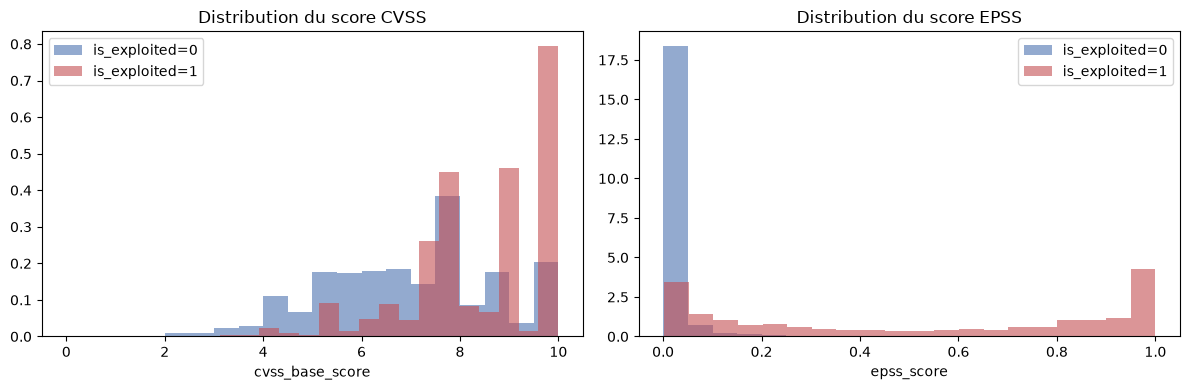

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
    subset = features[features["is_exploited"] == label]
    axes[0].hist(subset["cvss_base_score"].dropna(), bins=20, alpha=0.6, color=color,
                 label=f"is_exploited={label}", density=True)
    axes[1].hist(subset["epss_score"].dropna(), bins=20, alpha=0.6, color=color,
                 label=f"is_exploited={label}", density=True)

axes[0].set_title("Distribution du score CVSS")
axes[0].set_xlabel("cvss_base_score")
axes[0].legend()

axes[1].set_title("Distribution du score EPSS")
axes[1].set_xlabel("epss_score")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Modélisation — comparaison aux résultats EPSS

Split **temporel** (les CVE les plus anciennes servent à l'entraînement, les plus récentes au test) — pas de split aléatoire, pour simuler un déploiement réel.

In [6]:
import json

with open(PROCESSED_DIR / "model_metrics.json") as f:
    metrics = json.load(f)

metrics_df = pd.DataFrame(metrics).T
metrics_df = metrics_df[["roc_auc", "pr_auc", "precision", "recall", "f1"]].sort_values("roc_auc", ascending=False)
metrics_df.style.background_gradient(cmap="Greens", subset=["roc_auc", "pr_auc"]).format("{:.3f}")

,roc_auc,pr_auc,precision,recall,f1
logistic_regression,0.992,0.552,0.117,0.889,0.207
xgboost,0.992,0.566,0.697,0.450,0.547
epss_baseline,0.982,0.540,0.675,0.450,0.540
random_forest,0.977,0.543,0.794,0.286,0.420
lightgbm,0.946,0.341,0.543,0.434,0.482


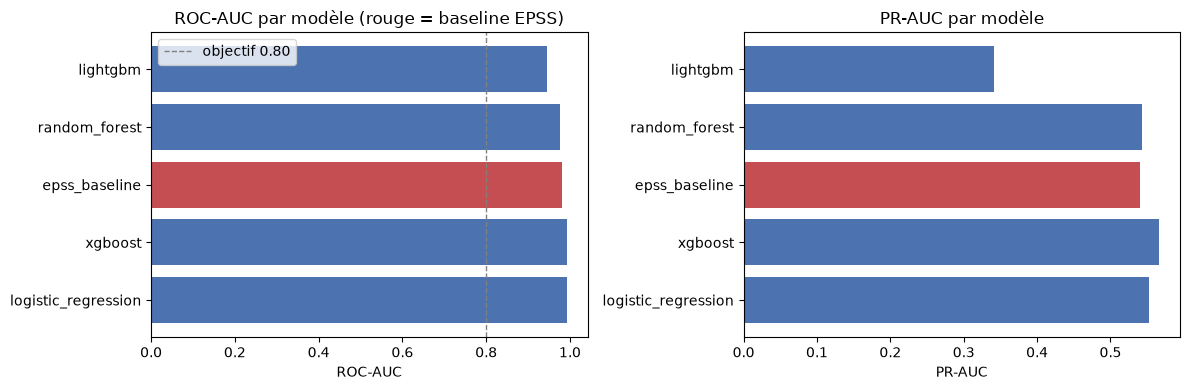

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#C44E52" if idx == "epss_baseline" else "#4C72B0" for idx in metrics_df.index]

axes[0].barh(metrics_df.index, metrics_df["roc_auc"], color=colors)
axes[0].set_xlabel("ROC-AUC")
axes[0].set_title("ROC-AUC par modèle (rouge = baseline EPSS)")
axes[0].axvline(0.80, color="gray", linestyle="--", linewidth=1, label="objectif 0.80")
axes[0].legend()

axes[1].barh(metrics_df.index, metrics_df["pr_auc"], color=colors)
axes[1].set_xlabel("PR-AUC")
axes[1].set_title("PR-AUC par modèle")

plt.tight_layout()
plt.show()

### Courbes ROC et Précision-Rappel sur le jeu de test

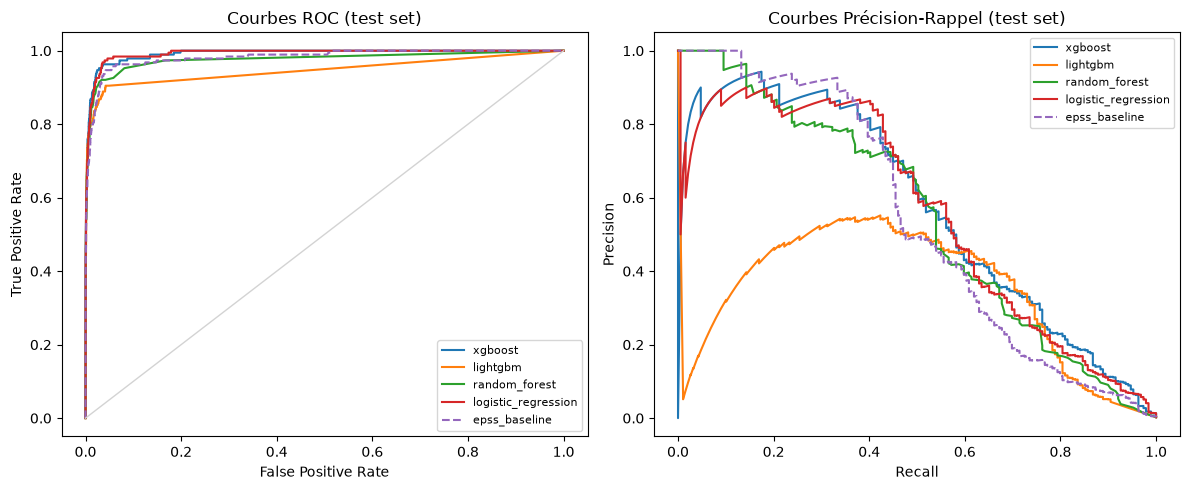

In [8]:
import joblib
from sklearn.metrics import precision_recall_curve, roc_curve

from src.models.dataset import get_X_y, load_features, temporal_split

df = load_features()
train_df, test_df = temporal_split(df, test_frac=0.2)
X_test, y_test = get_X_y(test_df)

model_names = ["xgboost", "lightgbm", "random_forest", "logistic_regression"]
scores = {}
for name in model_names:
    pipe = joblib.load(PROCESSED_DIR / "models" / f"{name}.joblib")
    scores[name] = pipe.predict_proba(X_test)[:, 1]
scores["epss_baseline"] = test_df["epss_score"].fillna(0.0).values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, y_score in scores.items():
    style = "--" if name == "epss_baseline" else "-"
    fpr, tpr, _ = roc_curve(y_test, y_score)
    axes[0].plot(fpr, tpr, style, label=name)

    prec, rec, _ = precision_recall_curve(y_test, y_score)
    axes[1].plot(rec, prec, style, label=name)

axes[0].plot([0, 1], [0, 1], color="lightgray", linewidth=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Courbes ROC (test set)")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Courbes Précision-Rappel (test set)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Feature importance — XGBoost

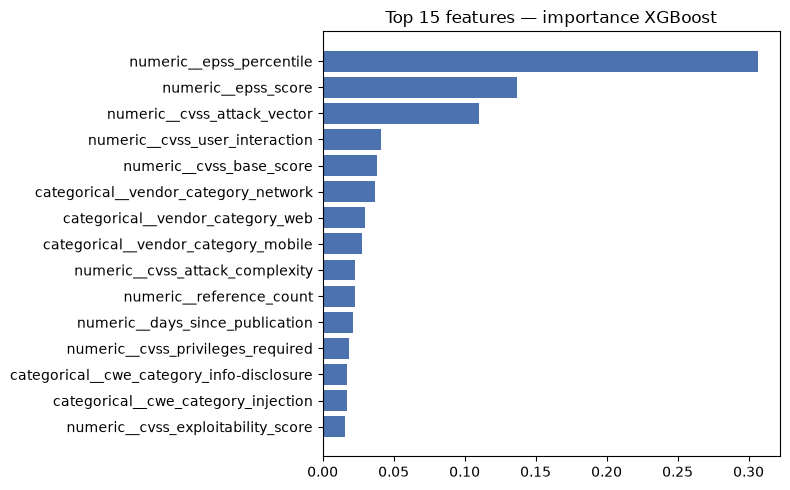

In [9]:
xgb_pipe = joblib.load(PROCESSED_DIR / "models" / "xgboost.joblib")
feature_names = xgb_pipe.named_steps["preprocess"].get_feature_names_out()
importances = xgb_pipe.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#4C72B0")
ax.set_title("Top 15 features — importance XGBoost")
plt.tight_layout()
plt.show()

## 4. Interprétabilité (SHAP)

`src/models/interpret.py` fournit deux fonctions réutilisées par le futur dashboard :
- `global_importance` : importance moyenne (|valeur SHAP|) sur un échantillon
- `explain_cve` : explication d'une CVE précise ("pourquoi ce score de risque ?")

C:\Users\manso\Documents\Projects\Projet-de-fin-d-eutde-DU-Data-Analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


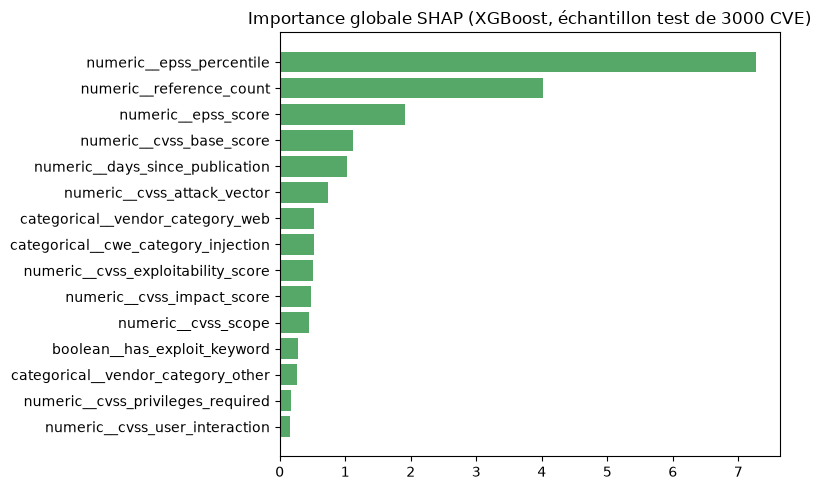

In [10]:
from src.models.interpret import explain_cve, global_importance

sample = test_df.sample(3000, random_state=42)
X_sample, _ = get_X_y(sample)
shap_importance = global_importance(xgb_pipe, X_sample)

fig, ax = plt.subplots(figsize=(8, 5))
top = shap_importance.head(15)
ax.barh(top["feature"][::-1], top["mean_abs_shap"][::-1], color="#55A868")
ax.set_title("Importance globale SHAP (XGBoost, échantillon test de 3000 CVE)")
plt.tight_layout()
plt.show()

### Deux exemples concrets

- **CVE-2026-31431** : CVSS modéré (7.8) mais EPSS très élevé (0.999) — effectivement exploitée (KEV). Le CVSS seul l'aurait sous-priorisée.
- **CVE-2026-39830** : CVSS très élevé (9.1, "critique") mais EPSS quasi nul (0.006) — jamais exploitée. Un tri par CVSS seul l'aurait mise en tête des priorités, à tort.

In [11]:
for cve_id in ["CVE-2026-31431", "CVE-2026-39830"]:
    explanation = explain_cve(cve_id, test_df, xgb_pipe)
    print(f"{cve_id} — probabilité prédite : {explanation['predicted_probability']:.4f}")
    for c in explanation["top_contributions"][:5]:
        print(f"    {c['feature']:45s} SHAP={c['shap_value']:+.3f}")
    print()

CVE-2026-31431 — probabilité prédite : 1.0000
    numeric__epss_percentile                      SHAP=+6.569
    numeric__epss_score                           SHAP=+2.706
    numeric__days_since_publication               SHAP=+1.212
    numeric__cvss_attack_vector                   SHAP=+1.122
    numeric__reference_count                      SHAP=+0.693

CVE-2026-39830 — probabilité prédite : 0.0000
    numeric__epss_percentile                      SHAP=-7.464
    numeric__reference_count                      SHAP=-7.239
    numeric__epss_score                           SHAP=-3.065
    numeric__cvss_base_score                      SHAP=-1.852
    numeric__cvss_impact_score                    SHAP=-1.207



## Conclusion

- Modèles entraînés sur un split **temporel** (train = CVE les plus anciennes, test = les plus récentes), pour simuler un déploiement réel.
- Le déséquilibre extrême de la cible (~0.4% de CVE exploitées) a été traité différemment selon le modèle : `class_weight='balanced'` (Random Forest, régression logistique), `scale_pos_weight` (XGBoost) — **LightGBM a volontairement été laissé sans repondération**, celle-ci dégradant fortement son AUC de test (0.95 → 0.69) sur ce ratio ~200:1, contrairement aux autres modèles.
- Voir le tableau et les graphiques ci-dessus pour la comparaison détaillée à la baseline EPSS et la vérification de l'objectif AUC-ROC > 0.80.
- SHAP confirme le mécanisme au cœur du projet : `epss_percentile`/`epss_score` et `reference_count` dominent l'importance globale, et les deux exemples ci-dessus illustrent concrètement les cas où CVSS seul aurait mal priorisé.
- Suivi complet des runs (paramètres, métriques, artefacts modèle) disponible via MLflow : `mlflow ui --backend-store-uri sqlite:///../mlruns/mlflow.db` depuis la racine du projet.